# XGBoost for Manhattan Data

In [956]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit


import xgboost as xgb
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [957]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

In [958]:
df

,ds,y
0,2020-01-01,4
1,2020-01-02,7
2,2020-01-03,16
3,2020-01-04,10
4,2020-01-05,5
...,...,...
2187,2025-12-27,5
2188,2025-12-28,2
2189,2025-12-29,6
2190,2025-12-30,10


In [959]:
df = df.set_index('ds')
df.index = pd.to_datetime(df.index)

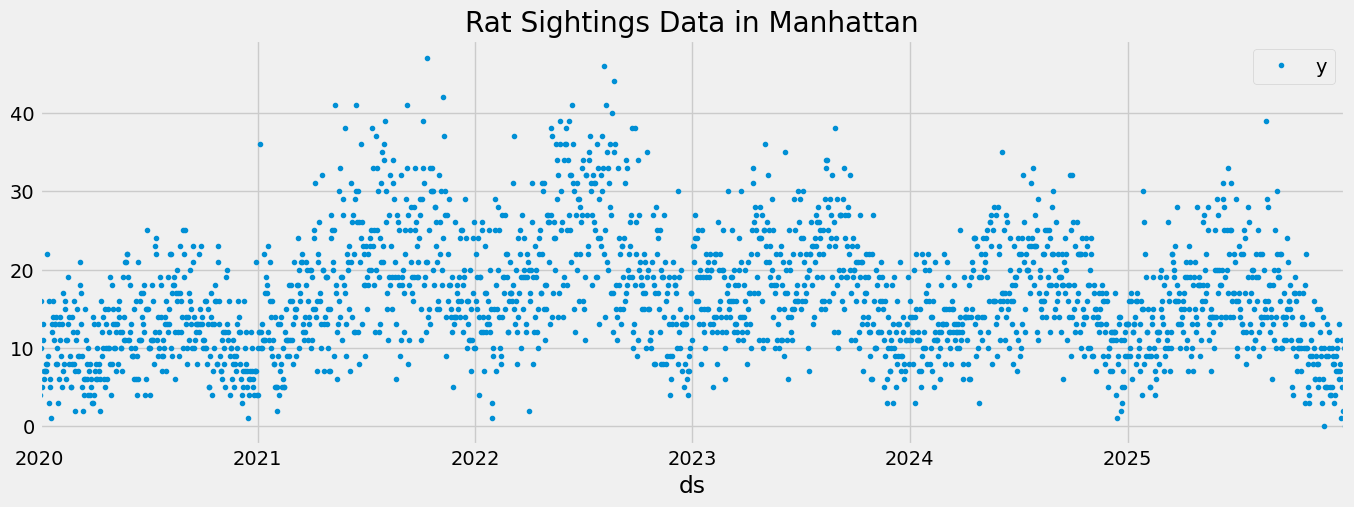

In [960]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='Rat Sightings Data in Manhattan')
plt.show()

## Cross-Validation

In [961]:
# tss = TimeSeriesSplit(n_splits=5, test_size=365, gap=0)
# df = df.sort_index()



In [962]:
# fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

# fold = 0
# for train_idx, val_idx in tss.split(df):
#     train = df.iloc[train_idx]
#     test = df.iloc[val_idx]
#     train['y'].plot(ax=axs[fold],
#                           label='Training Set',
#                           title=f'Data Train/Test Split Fold {fold}')
#     test['y'].plot(ax=axs[fold],
#                          label='Test Set')
#     axs[fold].axvline(test.index.min(), color='black', ls='--')
#     fold += 1
# plt.show()



## Add Features for XGBoost

In [963]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [964]:
df

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
ds,,,,,,,,
2020-01-01,4,2,1,1,2020,1,1,1
2020-01-02,7,3,1,1,2020,2,2,1
2020-01-03,16,4,1,1,2020,3,3,1
2020-01-04,10,5,1,1,2020,4,4,1
2020-01-05,5,6,1,1,2020,5,5,1
...,...,...,...,...,...,...,...,...
2025-12-27,5,5,4,12,2025,361,27,52
2025-12-28,2,6,4,12,2025,362,28,52
2025-12-29,6,0,4,12,2025,363,29,1


In [965]:
def add_lags(df):
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    target_map = df['y'].to_dict()
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    
    # Ensure sorted by date
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    df['ma7'] = df['y'].shift(1).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(1).rolling(window=30).mean()
    df['ma365'] = df['y'].shift(1).rolling(window=365).mean()
    
    return df


In [966]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-12-31"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

wd = pd.DataFrame(data["daily"])
wd["date"] = pd.to_datetime(wd["time"])
wd = wd.set_index("date")

wd

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,snowfall_sum
date,,,,,,,,,
2020-01-01,2020-01-01,4.4,-1.0,2.0,-2.0,-5.4,-3.6,0.0,0.00
2020-01-02,2020-01-02,8.7,-2.1,2.7,4.5,-6.6,-1.5,0.0,0.00
2020-01-03,2020-01-03,9.4,2.2,6.7,7.3,-1.1,4.3,4.8,0.00
2020-01-04,2020-01-04,9.6,4.3,7.5,7.9,-1.0,5.4,5.9,0.00
2020-01-05,2020-01-05,5.1,-1.2,2.5,-2.3,-5.0,-3.6,0.4,0.00
...,...,...,...,...,...,...,...,...,...
2025-12-27,2025-12-27,-0.8,-7.9,-3.9,-5.5,-12.2,-8.3,4.5,3.01
2025-12-28,2025-12-28,1.3,-11.4,-5.4,-2.3,-15.6,-9.2,0.9,0.00
2025-12-29,2025-12-29,7.2,-2.0,3.1,2.9,-8.0,-1.1,3.8,0.00


In [967]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [968]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    # Create holiday calendar
    cal = USFederalHolidayCalendar()
    
    # Generate holidays within your date range
    holidays = cal.holidays(
        start=df.index.min(),
        end=df.index.max()
    )
    
    # Create indicator column
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [969]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format → recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD → one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [970]:
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())

holidays    

DatetimeIndex(['2020-01-01', '2020-01-20', '2020-02-17', '2020-05-25',
               '2020-07-03', '2020-09-07', '2020-10-12', '2020-11-11',
               '2020-11-26', '2020-12-25', '2021-01-01', '2021-01-18',
               '2021-02-15', '2021-05-31', '2021-06-18', '2021-07-05',
               '2021-09-06', '2021-10-11', '2021-11-11', '2021-11-25',
               '2021-12-24', '2021-12-31', '2022-01-17', '2022-02-21',
               '2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05',
               '2022-10-10', '2022-11-11', '2022-11-24', '2022-12-26',
               '2023-01-02', '2023-01-16', '2023-02-20', '2023-05-29',
               '2023-06-19', '2023-07-04', '2023-09-04', '2023-10-09',
               '2023-11-10', '2023-11-23', '2023-12-25', '2024-01-01',
               '2024-01-15', '2024-02-19', '2024-05-27', '2024-06-19',
               '2024-07-04', '2024-09-02', '2024-10-14', '2024-11-11',
               '2024-11-28', '2024-12-25', '2025-01-01', '2025-01-20',
      

In [971]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    # Convert start_date to datetime
    start_dt = pd.to_datetime(start_date)
    
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [972]:
df = add_lags(df)
df = add_seasonal_lags(df)
df = add_moving_averages(df)
df = add_weather_data(df,wd)
df = add_federal_holidays(df, custom_holidays = ['12-31'])
df = add_law_flag(df, law_name='Trash_Law', start_date = '2024-03-01')
df = add_law_flag(df, law_name = 'New_Trash_Law', start_date = '2024-11-01')
df = add_law_flag(df, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
df = add_law_flag(df, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')
df

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,...,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,snowfall_sum,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,4,2,1,1,2020,1,1,1,NaN,NaN,...,-2.0,-5.4,-3.6,0.0,0.00,1,0,0,0,0
2020-01-02,7,3,1,1,2020,2,2,1,4.0,NaN,...,4.5,-6.6,-1.5,0.0,0.00,0,0,0,0,0
2020-01-03,16,4,1,1,2020,3,3,1,7.0,4.0,...,7.3,-1.1,4.3,4.8,0.00,0,0,0,0,0
2020-01-04,10,5,1,1,2020,4,4,1,16.0,7.0,...,7.9,-1.0,5.4,5.9,0.00,0,0,0,0,0
2020-01-05,5,6,1,1,2020,5,5,1,10.0,16.0,...,-2.3,-5.0,-3.6,0.4,0.00,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,5,5,4,12,2025,361,27,52,11.0,1.0,...,-5.5,-12.2,-8.3,4.5,3.01,0,1,1,1,1
2025-12-28,2,6,4,12,2025,362,28,52,5.0,11.0,...,-2.3,-15.6,-9.2,0.9,0.00,0,1,1,1,1
2025-12-29,6,0,4,12,2025,363,29,1,2.0,5.0,...,2.9,-8.0,-1.1,3.8,0.00,0,1,1,1,1


In [973]:
df.columns

Index(['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7',
       'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag365',
       'lag730', 'lag1095', 'lag1460', 'ma7', 'ma30', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'is_federal_holiday', 'Trash_Law', 'New_Trash_Law',
       'Rat_Mitigation_Zone', 'Rat_Czar_Appointed'],
      dtype='object')

## Train using Cross-Validation

In [974]:
# params = {'base_score': 0.8308949532860567, 
#           'n_estimators': 958, 
# #          'early_stopping_rounds': 48, 
#           'learning_rate': 0.06446096958633958, 
#           'max_depth': 6, 
#           'subsample': 0.5630169564135505, 
#           'colsample_bytree': 0.6954848029608272, 
#           'colsample_bylevel': 0.696639477506487, 
#           'colsample_bynode': 0.897501038077366, 
#           'reg_alpha': 0.0166687220746786, 
#           'gamma': 4.459627688454813, 
#           'reg_lambda': 7.92022921471379,
#           'objective': 'reg:squarederror',
#           'eval_metric': 'rmse',
#           'booster': 'gbtree'}

In [975]:
# params = {'n_estimators': 427, 
#           'max_depth': 3, 
#           'learning_rate': 0.03127549462906121, 
#           'subsample': 0.645884729103543, 
#           'colsample_bytree': 0.9803635824375493, 
#           'min_child_weight': 6, 
#           'gamma': 1.084829875368503, 
#           'reg_alpha': 3.3520123510101397e-06, 
#           'reg_lambda': 0.6164264586533088,}

In [976]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 3.1187948816355946, 
         'n_estimators': 2000, 
         'early_stopping_rounds': 100, 
         'min_child_weight': 4, 
         'learning_rate': 0.0032277276331029773,
         'max_depth': 4, 
         'subsample': 0.8256697776794805, 
         'colsample_bytree': 0.5604360617000728, 
         'colsample_bylevel': 0.6561790404302128, 
         'colsample_bynode': 0.9022647171625393, 
         'reg_alpha': 0.1250911583628693, 
         'gamma': 2.433711545428995, 
         'reg_lambda': 0.0012664508500758675}

In [977]:
tss = TimeSeriesSplit(n_splits=8, test_size=14, gap=0) # We might consider choosing a gap of 1 since the data sometimes has reporting delays of 1 day. 
df = df.sort_index()


fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'dayofmonth', 'dayofweek', 'month',
                'lag1', 'lag2','lag3', 'lag4', 'lag5', 'lag6', 'lag7',
                'lag365', 'lag730',
                'ma30',
                'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                'precipitation_sum', 'snowfall_sum', 
                'is_federal_holiday',
                'Trash_Law', 'New_Trash_Law', 'Rat_Mitigation_Zone']
    TARGET = 'y'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]
    
    split_index_train = int(len(X_train)-14)  # Save 14 days for validation
    split_index_train = int(len(y_train)-14)
    X_train2, X_val = X_train[:split_index_train], X_train[split_index_train:]
    y_train2, y_val = y_train[:split_index_train], y_train[split_index_train:]
    

    reg = xgb.XGBRegressor(**params)
    reg.fit(X_train2, y_train2, eval_set=[(X_val,y_val)], verbose=False)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

print(f'Average score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')


Average score across folds 4.1020
Fold scores:[5.164489451431314, 5.239410984043607, 3.374522846541937, 5.431327385565103, 3.1962414722530266, 4.184925255694772, 2.456961189569005, 3.7685214098281317]


Here, we record the best performing parameters so far.

In [978]:
reg.get_xgb_params()

{'objective': 'reg:squarederror',
 'base_score': 3.1187948816355946,
 'booster': 'gbtree',
 'colsample_bylevel': 0.6561790404302128,
 'colsample_bynode': 0.9022647171625393,
 'colsample_bytree': 0.5604360617000728,
 'device': None,
 'eval_metric': 'rmse',
 'gamma': 2.433711545428995,
 'grow_policy': None,
 'interaction_constraints': None,
 'learning_rate': 0.0032277276331029773,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 4,
 'max_leaves': None,
 'min_child_weight': 4,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': 0.1250911583628693,
 'reg_lambda': 0.0012664508500758675,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8256697776794805,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

## GridSearch for Hyperparameter Tuning

In [979]:
from sklearn.model_selection import GridSearchCV

In [980]:
param_grid = {
    'base_score': [10],
    'n_estimators': [1000],
    'learning_rate': [0.1],
    'max_depth': [3],
    'subsample': [0.8],
    'colsample_bytree': [0.4],
    'colsample_bylevel': [0.6],
    'colsample_bynode': [1],
    'gamma': [2],
    'reg_lambda': [1.2],
    'alpha': [0.6]
}

# {'alpha': 0.6, 'base_score': 10, 'colsample_bylevel': 0.6, 'colsample_bynode': 1, 'colsample_bytree': 0.4, 'gamma': 2, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1000, 'reg_lambda': 1.2, 'subsample': 0.8}
# Running the grid search, it seems base_score of 10 is genuinely better than the default of 0.5.

In [981]:
model_for_grid = xgb.XGBRegressor(booster='gbtree',    
                           objective='reg:squarederror',
                           early_stopping_rounds=50,
                           eval_metric = 'rmse',
                           verbosity = 0,
                           randomstate = 42)

In [982]:
feature_cols = df.columns.difference(['y'])
target_col = 'y'
X = df[feature_cols].copy()
y = df[target_col].copy()
split_index = int(len(X) * 0.8)  # 80% of data for training
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [983]:
from sklearn.model_selection import RandomizedSearchCV

def grid(param_grid, model, random=False):
    if random:
        clf = RandomizedSearchCV(model, param_grid, scoring = 'neg_mean_squared_error', cv=tss, n_iter = 2)
    else:
        clf = GridSearchCV(model, param_grid=param_grid, scoring = 'neg_mean_squared_error', cv=tss)
    clf.fit(X_train, y_train, eval_set=[(X_train, y_train)])
    best_model = clf.best_estimator_
    best_params = clf.best_params_
    print(best_model)
    print(best_params)

In [984]:
# grid(param_grid, model_for_grid, random=False)

In [985]:
# y_pred = best_model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# print(f"Best Hyperparameters: {best_params}")
# print(f"Test Set Mean Squared Error: {mse:.4f}")

## Optuna for Hyperparameter Tuning

In [986]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [987]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [988]:
# feature_cols = df.columns.difference(['y'])
# target_col = 'y'
# X = df[feature_cols].copy()
# y = df[target_col].copy()
# split_index = int(len(X) * 0.8)  # 80% of data for training
# X_train, X_test = X[:split_index], X[split_index:]
# y_train, y_test = y[:split_index], y[split_index:]

In [989]:
# def objective(trial: optuna.Trial) -> float:
#     # Define the search space for hyperparameters

    # params = {
    #     "base_score": trial.suggest_float("base_score", 0.5, 10),
    #     "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
    #     # "early_stopping_rounds": trial.suggest_int("early_stopping_rounds", 10, 100),
    #     "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 5),
    #     "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
    #     "max_depth": trial.suggest_int("max_depth", 3, 12),
    #     "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    #     "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    #     "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
    #     "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
    #     "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    #     "gamma": trial.suggest_float("gamma", 1, 5),
    #     "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    #     "random_state": 42,
    #     'objective': 'reg:squarederror',
    #     'eval_metric': 'rmse',
    #     'booster': 'gbtree'
    # }

#     model = XGBRegressor(**params)

#     # Fit model
#     model.fit(
#         X_train, y_train,
#         # eval_set=[(X_test, y_test)],
#         verbose=False
#     )

#     # Predict and compute a regression metric
#     preds = model.predict(X_test)
#     metric_rmse = np.sqrt(mean_squared_error(y_test, preds))
#     return metric_rmse  # Optuna tries to minimize RMSE

# # Create a study that minimizes the objective
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=1000)

# print("Best RMSE:", study.best_value)
# print("Best hyperparameters:", study.best_params)

In [990]:
ntss = tss # Use this if you wish to use the same TimeSeriesSplit as the cross validation.
# ntss = TimeSeriesSplit(n_splits=10, test_size=30, gap=0) 

df = df.sort_index()

FEATURES = ['dayofyear', 'dayofmonth', 'dayofweek', 'month',
            'lag1', 'lag2','lag3', 'lag4', 'lag5', 'lag6', 'lag7',
            'lag365', 'lag730',
            'ma30',
            'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
            'precipitation_sum', 'snowfall_sum', 
            'is_federal_holiday',
            'Trash_Law', 'New_Trash_Law', 'Rat_Mitigation_Zone']

TARGET = 'y'


def objective(trial):

    params = {"base_score": trial.suggest_float("base_score", 0.5, 15),
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "early_stopping_rounds": 100,
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': 'gbtree'
    }

    scores = []

    for fold, (train_idx, val_idx) in enumerate(ntss.split(df)):

        train = df.iloc[train_idx]
        test = df.iloc[val_idx]

        train = create_features(train)
        test = create_features(test)

        X_train = train[FEATURES]
        y_train = train[TARGET]

        X_test = test[FEATURES]
        y_test = test[TARGET]
        
        split_index_train = int(len(X_train) -14)  # 14 days for validation
        split_index_train = int(len(y_train) -14)
        X_train2, X_val = X_train[:split_index_train], X_train[split_index_train:]
        y_train2, y_val = y_train[:split_index_train], y_train[split_index_train:]
    

        reg = xgb.XGBRegressor(**params)
        reg.fit(X_train2, y_train2, eval_set=[(X_val,y_val)], verbose=False)

        y_pred = reg.predict(X_test)

        score = np.sqrt(mean_squared_error(y_test, y_pred))
        scores.append(score)

        trial.report(score, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-03 12:14:30,654] A new study created in memory with name: no-name-82afe638-55f5-4809-b34a-ac8a12ef8be2
[I 2026-03-03 12:14:42,430] Trial 0 finished with value: 4.359679942420602 and parameters: {'base_score': 8.434052274381337, 'learning_rate': 0.014775187564697072, 'max_depth': 7, 'subsample': 0.8478140263979873, 'colsample_bytree': 0.4444642118993855, 'min_child_weight': 9}. Best is trial 0 with value: 4.359679942420602.
[I 2026-03-03 12:15:18,379] Trial 1 finished with value: 4.892041333192246 and parameters: {'base_score': 14.994385804103654, 'learning_rate': 0.004528287575827067, 'max_depth': 9, 'subsample': 0.21501640466230487, 'colsample_bytree': 0.07194891392173021, 'min_child_weight': 15}. Best is trial 0 with value: 4.359679942420602.
[I 2026-03-03 12:16:03,971] Trial 2 finished with value: 4.252652832640365 and parameters: {'base_score': 9.298326117826036, 'learning_rate': 0.0011189924392066277, 'max_depth': 9, 'subsample': 0.6620104603380459, 'colsample_bytree': 

In [991]:
print("Best RMSE:", study.best_value)
print("Best hyperparameters:", study.best_params)

Best RMSE: 4.089705005781255
Best hyperparameters: {'base_score': 6.665010486648244, 'learning_rate': 0.010254084543969763, 'max_depth': 7, 'subsample': 0.709608591997632, 'colsample_bytree': 0.8128415371484969, 'min_child_weight': 10}


Best RMSE: 4.5949824421703385

Best hyperparameters: {'base_score': 3.5296645373286357, 'n_estimators': 981, 'early_stopping_rounds': 67, 'min_child_weight': 4.674539626155998, 'learning_rate': 0.0013271979620867002, 'max_depth': 8, 'subsample': 0.9192206200660122, 'colsample_bytree': 0.7210329785967433, 'colsample_bylevel': 0.9062368200722201, 'colsample_bynode': 0.7739395940894417, 'reg_alpha': 0.06193643892558859, 'gamma': 3.8095742418896945, 'reg_lambda': 0.0010666334134429216}


Best RMSE: 4.996325184613163

Best hyperparameters: {'learning_rate': 0.04701562844745464, 'early_stopping_rounds': 61, 'max_depth': 2, 'subsample': 0.606267933476189, 'colsample_bytree': 0.5138220023226355, 'min_child_weight': 3}

In [992]:
params.update(study.best_params)

## Forecasting

In [993]:
# The following parameters will be used are being used.

params

{'objective': 'reg:squarederror',
 'eval_metric': 'rmse',
 'booster': 'gbtree',
 'base_score': 6.665010486648244,
 'n_estimators': 2000,
 'early_stopping_rounds': 100,
 'min_child_weight': 10,
 'learning_rate': 0.010254084543969763,
 'max_depth': 7,
 'subsample': 0.709608591997632,
 'colsample_bytree': 0.8128415371484969,
 'colsample_bylevel': 0.6561790404302128,
 'colsample_bynode': 0.9022647171625393,
 'reg_alpha': 0.1250911583628693,
 'gamma': 2.433711545428995,
 'reg_lambda': 0.0012664508500758675}

In [994]:
print(f"The following parameters were used.\n{params}")

FEATURES = ['dayofyear', 'dayofmonth', 'dayofweek', 'month',
        'lag1', 'lag2','lag3', 'lag4', 'lag5', 'lag6', 'lag7',
        'lag365', 'lag730',
        'ma30', 'ma7',
        'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
        'precipitation_sum', 'snowfall_sum', 
        'is_federal_holiday',
        'Trash_Law', 'New_Trash_Law', 'Rat_Mitigation_Zone']

X_all = df[FEATURES]
y_all = df[TARGET]

split_index_train = int(len(X_all) -14)  # Save 14 days for validation
split_index_train = int(len(y_all) -14)
X_train, X_val = X_all[:split_index_train], X_all[split_index_train:]
y_train, y_val = y_all[:split_index_train], y_all[split_index_train:]

reg = xgb.XGBRegressor(**params)

reg.fit(X_train, y_train, eval_set=[(X_val,y_val)])

The following parameters were used.
{'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'booster': 'gbtree', 'base_score': 6.665010486648244, 'n_estimators': 2000, 'early_stopping_rounds': 100, 'min_child_weight': 10, 'learning_rate': 0.010254084543969763, 'max_depth': 7, 'subsample': 0.709608591997632, 'colsample_bytree': 0.8128415371484969, 'colsample_bylevel': 0.6561790404302128, 'colsample_bynode': 0.9022647171625393, 'reg_alpha': 0.1250911583628693, 'gamma': 2.433711545428995, 'reg_lambda': 0.0012664508500758675}
[0]	validation_0-rmse:3.81549
[1]	validation_0-rmse:3.81897
[2]	validation_0-rmse:3.82307
[3]	validation_0-rmse:3.82025
[4]	validation_0-rmse:3.81822
[5]	validation_0-rmse:3.81980
[6]	validation_0-rmse:3.82048
[7]	validation_0-rmse:3.82310
[8]	validation_0-rmse:3.82172
[9]	validation_0-rmse:3.81857
[10]	validation_0-rmse:3.81455
[11]	validation_0-rmse:3.81805
[12]	validation_0-rmse:3.81717
[13]	validation_0-rmse:3.81523
[14]	validation_0-rmse:3.81717
[15]	validation_

,objective,'reg:squarederror'
,base_score,6.665010486648244
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,0.6561790404302128
,colsample_bynode,0.9022647171625393
,colsample_bytree,0.8128415371484969
,device,None
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,'rmse'


In [995]:
# Create future dataframe
future = pd.date_range('2026-01-01','2026-12-31', freq='1d')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)


In [996]:
future_w_features = df_and_future.query('isFuture').copy()

In [997]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

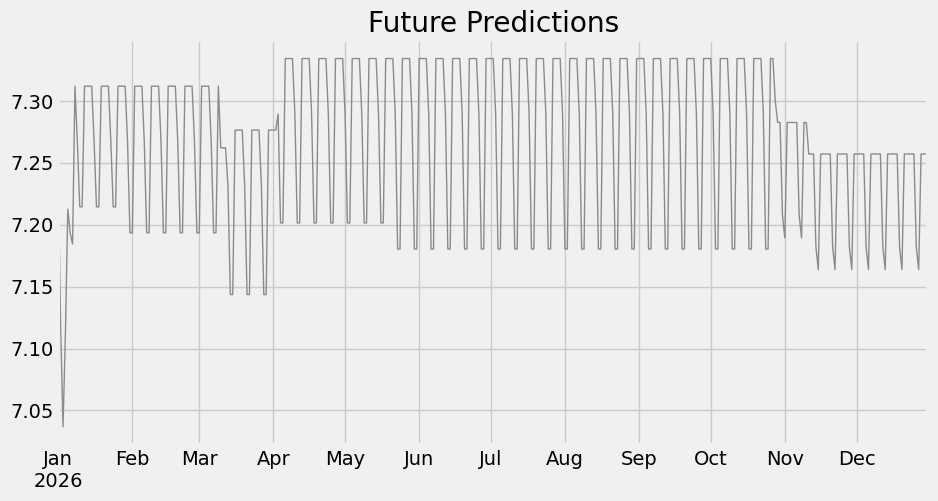

In [998]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

## Plots

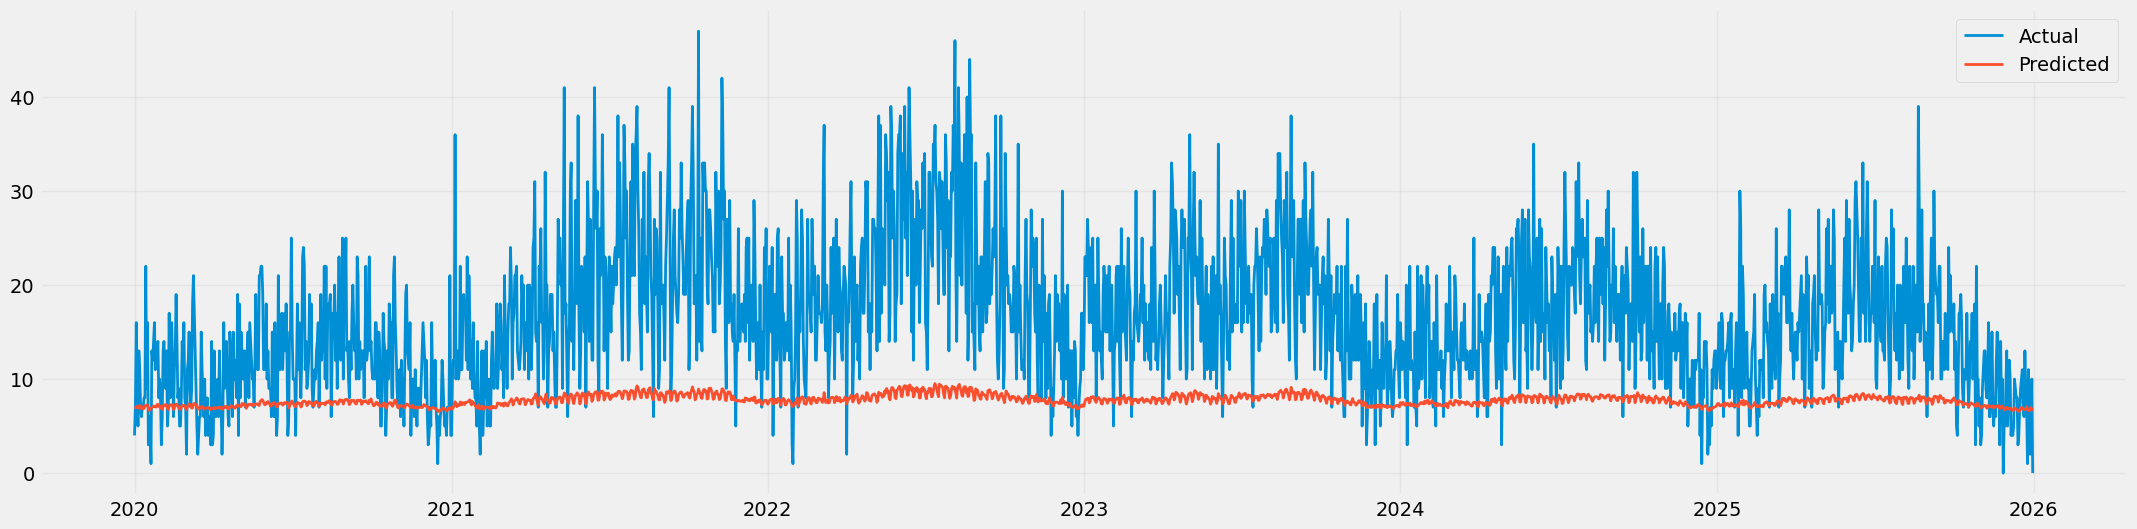

In [999]:
y_pred = reg.predict(X_all)

plt.figure(figsize=(24,6))
plt.plot(df.index, y_all.values, label="Actual", linewidth=2)
plt.plot(df.index, y_pred, label="Predicted", linewidth=2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [1000]:
np.sqrt(mean_squared_error(y_all,y_pred))

11.31697053197031

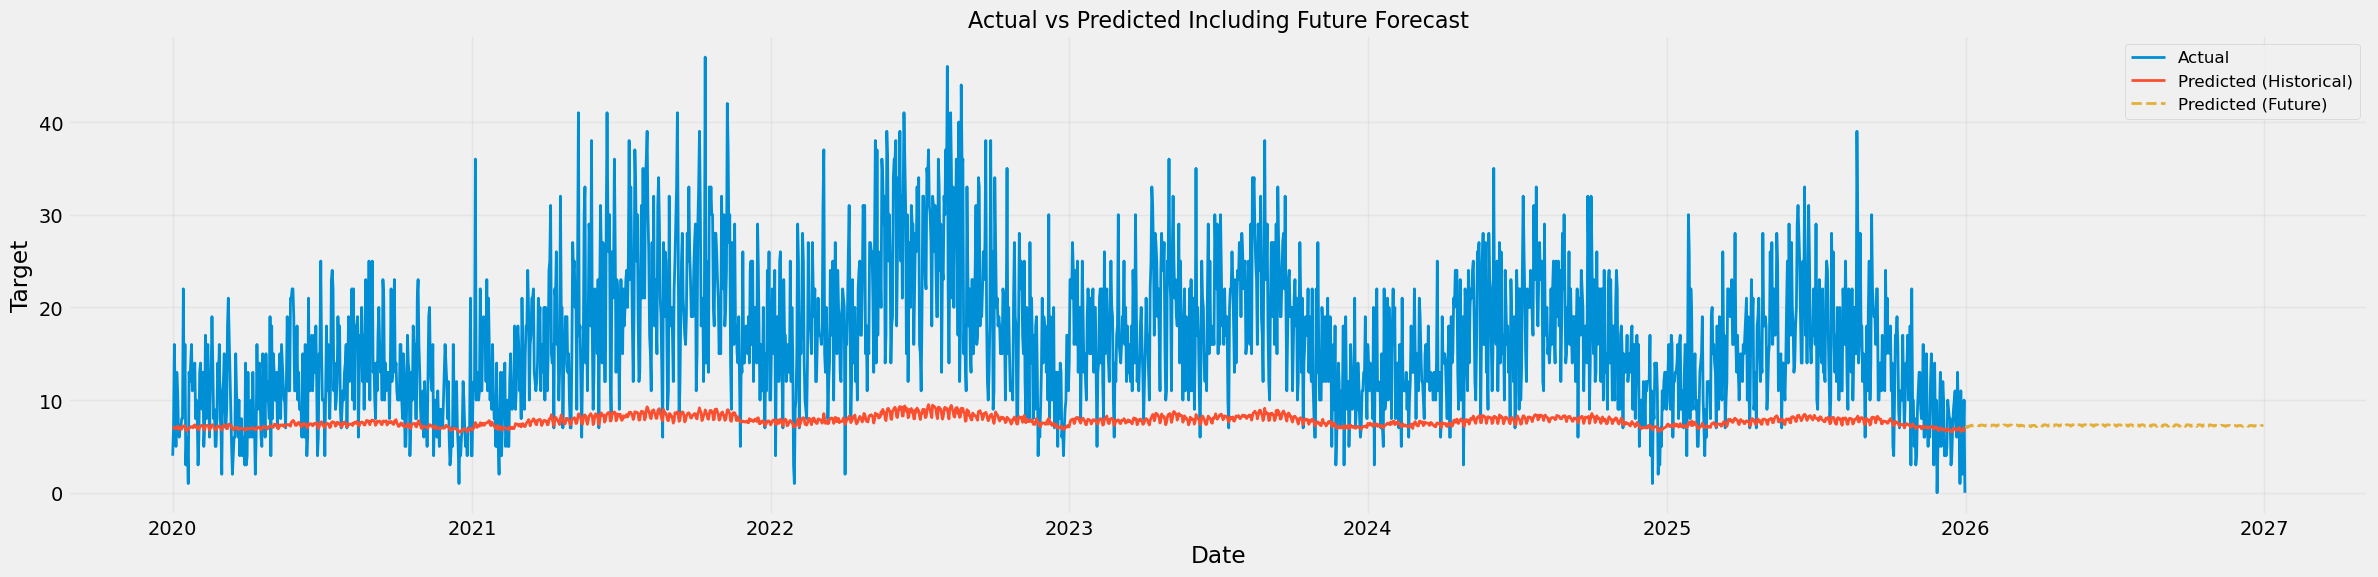

In [1001]:
import matplotlib.pyplot as plt

color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(24,6))

# Plot historical actuals
plt.plot(df.index, y_all.values,
         label="Actual",
         color=color_pal[0],
         linewidth=2)

# Plot historical predictions
plt.plot(df.index, y_pred,
         label="Predicted (Historical)",
         color=color_pal[1],
         linewidth=2)

# Plot future predictions (align index with future_w_features)
plt.plot(future_w_features.index, future_w_features['pred'],
         label="Predicted (Future)",
         color=color_pal[2],
         linewidth=2,
         linestyle='--')  # dashed to distinguish future

# Styling
plt.title("Actual vs Predicted Including Future Forecast", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We clearly should not be trying to forecast further than 7-14 days as the above plot will show. One example of why is that we have limited information on the weather far out into the future (weather forecasts become less accurate). 

On the other hand, if we look at the predictions below, we see that it is strikingly close to the actual numbers from 2026-01-01 to 2026-01-14.

In [1002]:
for d in range(14):
    print(y_pred[d])

6.9403114
6.9335637
7.0972357
7.050065
6.911499
6.9418054
7.193453
7.101179
6.835892
7.0537105
6.844871
6.882069
7.161687
7.1651626


### Plot against 2026 Data

In [1003]:
df26 = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs26.csv')
df26['created_date'] = pd.to_datetime(df26['created_date']) 
df26 = df26[df26['borough']=='MANHATTAN']
full_dates26 = pd.date_range('2026-01-01', '2026-12-31', freq='D')
full_index26 = pd.MultiIndex.from_product([['MANHATTAN'], full_dates26], names=['borough', 'created_date'])
df26 = df26.set_index(['borough', 'created_date']).reindex(full_index26).fillna({'count': 0}).reset_index()
df26['count'] = df26['count'].astype(int)
df26.drop(columns=['borough'], inplace=True)
df26 = df26.rename(columns = {'created_date' : 'ds', 'count':'y'})

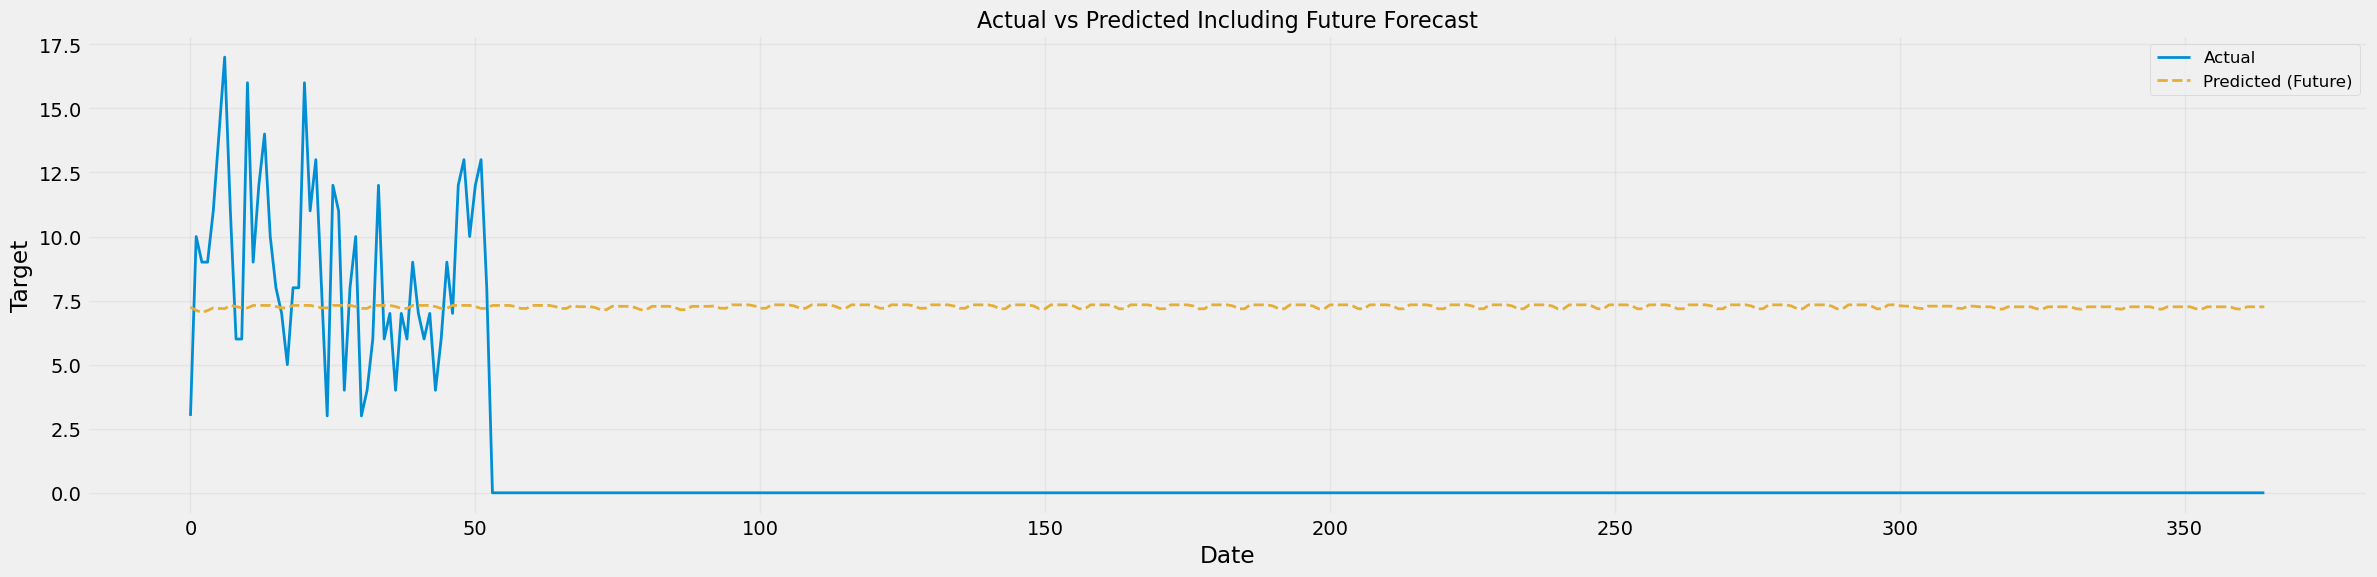

In [1004]:
import matplotlib.pyplot as plt

color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(24,6))

# Plot historical actuals
plt.plot(df26.index, df26['y'].values,
         label="Actual",
         color=color_pal[0],
         linewidth=2)

# Plot future predictions (align index with future_w_features)
plt.plot(df26.index, future_w_features['pred'],
         label="Predicted (Future)",
         color=color_pal[2],
         linewidth=2,
         linestyle='--')  # dashed to distinguish future

# Styling
plt.title("Actual vs Predicted Including Future Forecast", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot of Residuals

In [1005]:
residuals = y_pred-y_all.values

residuals

array([ 2.94031143, -0.06643629, -8.90276432, ...,  0.97823   ,
       -3.28080606,  6.80542898])

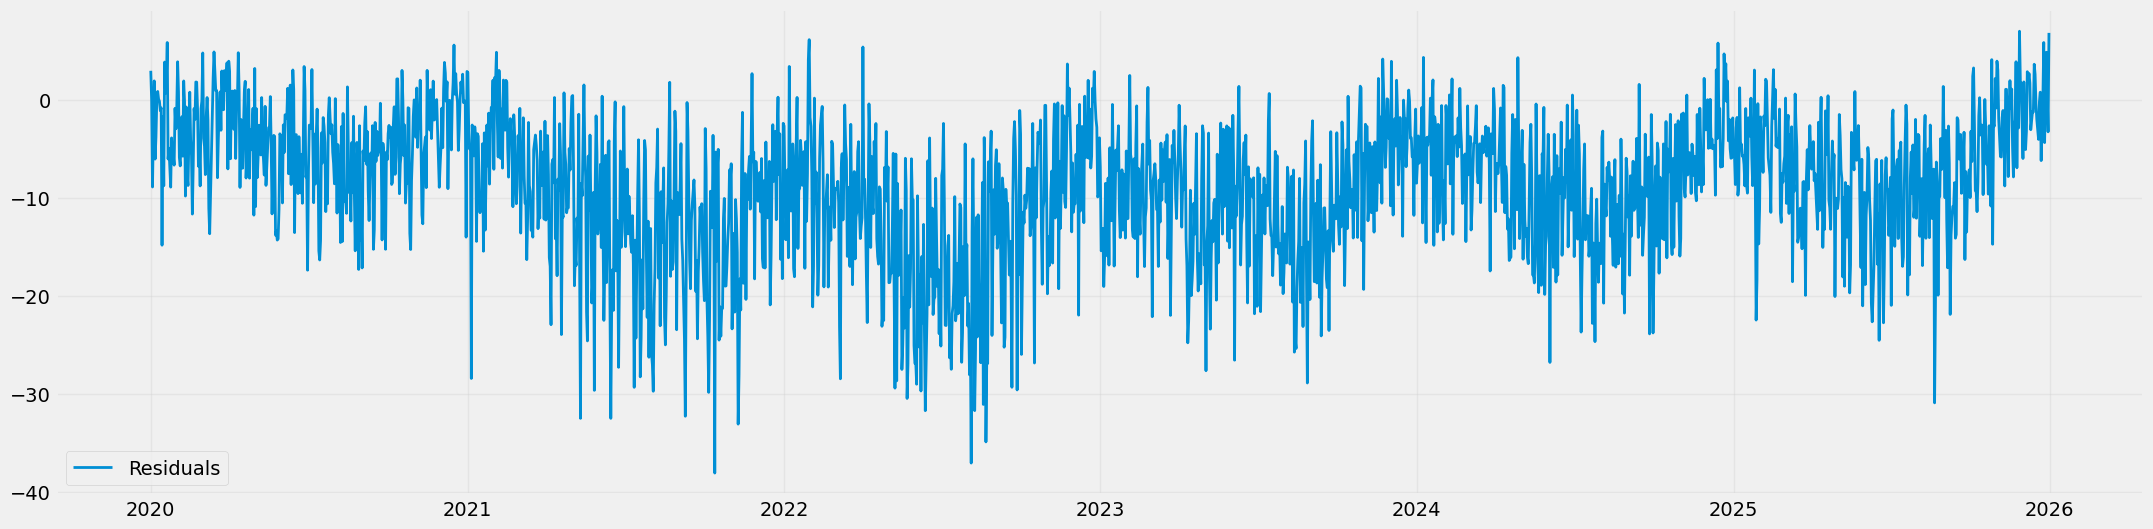

In [1006]:
y_pred = reg.predict(X_all)

residuals = y_pred-y_all.values

plt.figure(figsize=(24,6))
plt.plot(df.index, residuals, label="Residuals", linewidth=2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature Importance

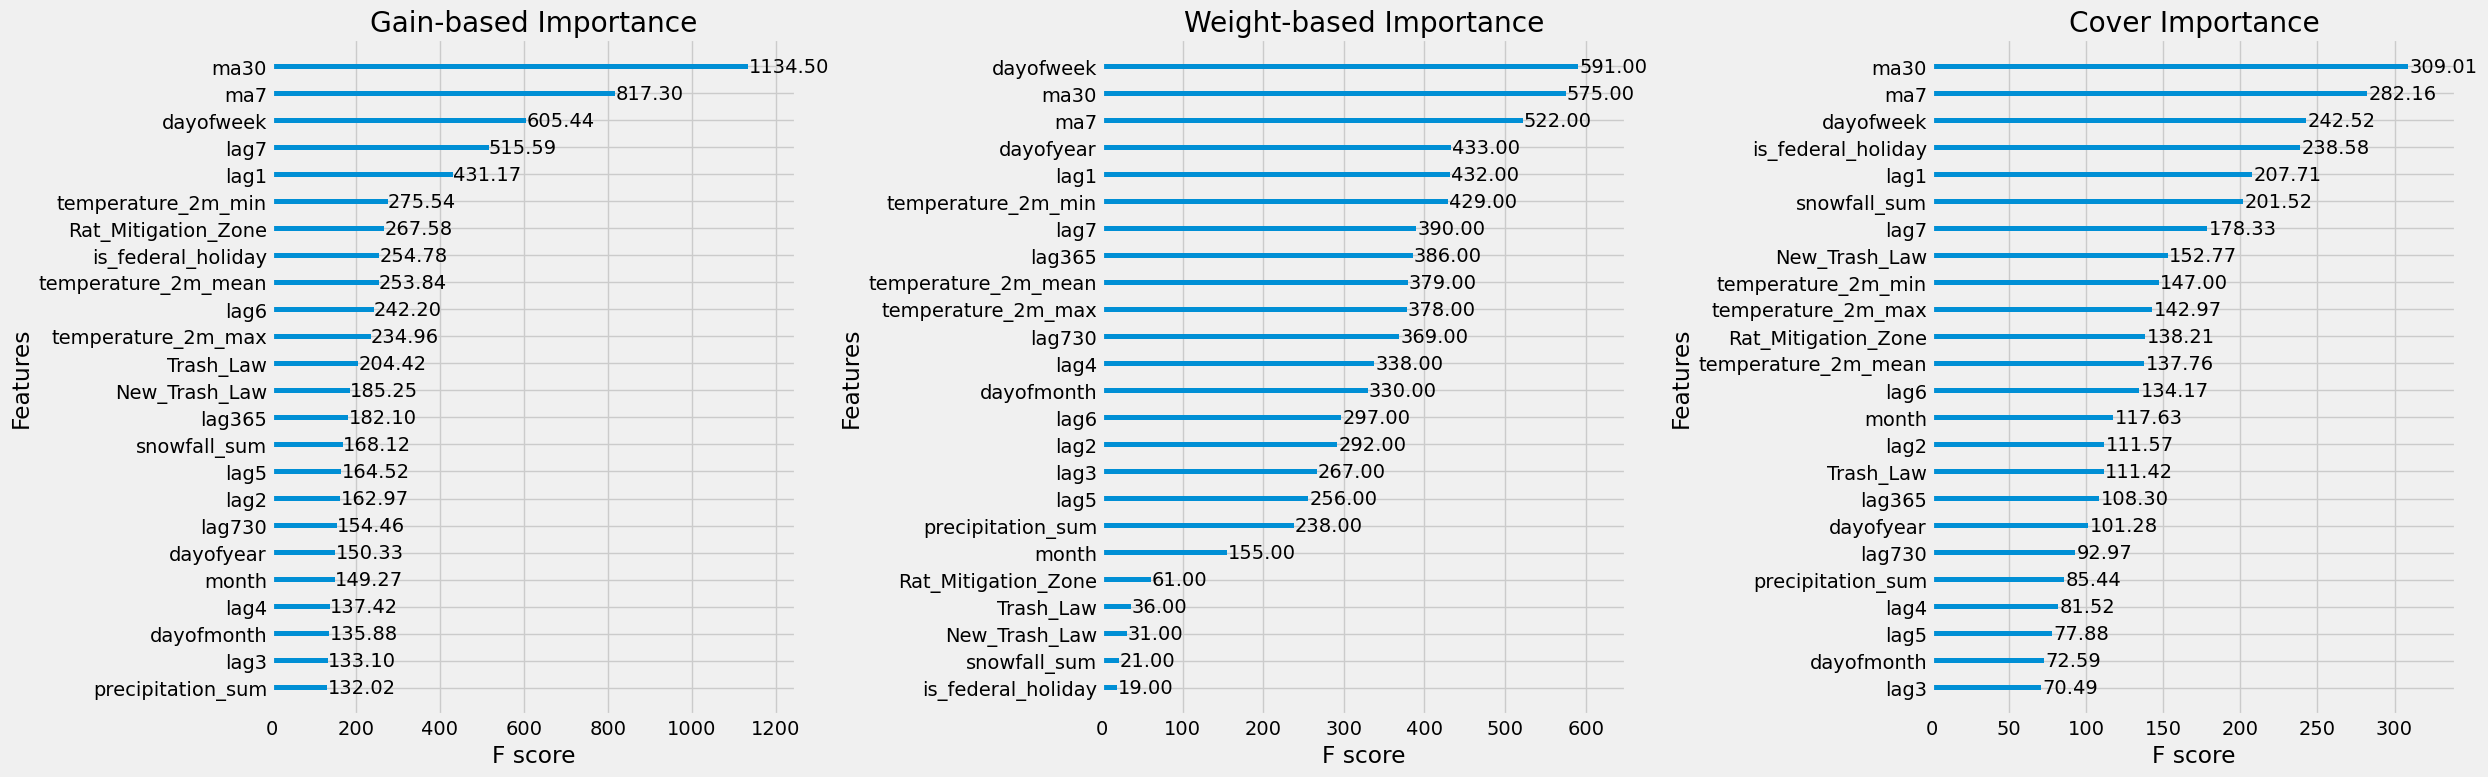

In [1007]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 8))

def plot_and_round(ax, importance_type, title):
    xgb.plot_importance(
        reg,
        ax=ax,
        importance_type=importance_type,
        show_values=True,
        values_format = '{v:.2f}'
    )
    ax.set_title(title)

# Gain
plot_and_round(ax1, 'gain', 'Gain-based Importance')

# Split
plot_and_round(ax2, 'weight', 'Weight-based Importance')

# Cover
plot_and_round(ax3, 'cover', 'Cover Importance')

plt.tight_layout()
plt.show()

From the xgboost documentation: 

    How the importance is calculated: either “weight”, “gain”, or “cover”

    ”weight” is the number of times a feature appears in a tree

    ”gain” is the average gain of splits which use the feature

    ”cover” is the average coverage of splits which use the feature where coverage is defined as the number of samples affected by the split


# Tree Visual

Uncomment the code below to examine the trees of the XGBoost model. Just remember to uncomment the codeblock to delete the .gv, .gv.png and .png files after.

In [1008]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [1009]:
# import xgboost as xgb

# node_params = {'shape': 'box', 'style': 'filled,rounded', 'fillcolor': '#78cbe'}
# leaf_params = {'shape': 'box', 'style': 'filled', 'fillcolor': '#e48038'}

# xgb.to_graphviz(reg, num_trees=3,
#                 condition_node_params=node_params,
#                 leaf_node_params=leaf_params).view()


In [1010]:
# files_to_delete = ["Source.gv.pdf", "Source.png", "Source.gv"]

# for file_name in files_to_delete:
#     file_path = os.path.join(os.getcwd(), file_name)
#     if os.path.exists(file_path):
#         os.remove(file_path)
#         print(f"Deleted: {file_name}")
#     else:
#         print(f"File not found: {file_name}")

# Transforming data before XGBoosting

https://xgboosting.com/xgboost-assumes-stationary-time-series-data/

We seem to do okay without assuming stationary?